In [2]:
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
from uncertainties import ufloat, std_dev, nominal_value
from uncertainties.unumpy import nominal_values, std_devs, uarray

# Create calibrated Spectrum 
from pyspectrum.core import Spectrum
from pyspectrum.io import TimeChannelParser
from pyspectrum.calibration.models.hpge_fwhm_model import StandardHPGeFWHMModel
from pyspectrum.calibration import AxisCalibration, ResolutionCalibration

# load the spectrum

In [3]:
path = '../Library/Doppler_broadening_Spectrum.txt'
df_spectrum = pd.read_csv(path, sep=' ', skiprows=5, names=['time','channel','flag'], usecols=[0,1,2])


# known calibration
energy_calib_poly = np.poly1d([0.0408976444, 0.0822321508])
# known resolution
energy_resolution = 1.05
estimated_FWHM = StandardHPGeFWHMModel().generator((0, energy_resolution/511**0.5, 0))


energy_calib = AxisCalibration(func=energy_calib_poly, name="energy")
res_calib = ResolutionCalibration(func=estimated_FWHM)

spectrum  = TimeChannelParser.from_file(path, axis_calib=energy_calib, resolution_calib=res_calib,
                                        num_of_channels=16384, chunk_size=int(10000),
                                        sep=' ', skiprows=5, names=['time','channel','flag'], usecols=[0,1,2])

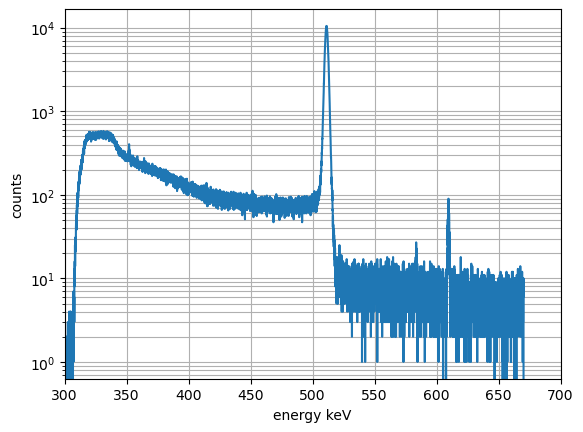

In [4]:
spectrum.plot(yscale='log')
plt.ylabel("counts")
plt.xlabel("energy keV")
plt.grid(True, which='both')
plt.xlim([300,700])
plt.show()

# find the domain around 511 keV above snr

In [5]:
# identification of peaks
from pyspectrum.identification import Convolution
from pyspectrum.identification.snr import SNRFinder
from pyspectrum.identification.kernels.mexican_hat import gaussian_2_dev

pyspecrtum use SNR method to find meaningfull domains. \
the convolution is not standard numpy function because the width depends on the axis 

In [6]:
conv = Convolution(resolution=res_calib.apply, kernel=gaussian_2_dev, window_fwhm=3)
finder = SNRFinder(convolution=conv, n_sigma_signal_threshold=4, n_sigma_bg_threshold=2.0, persistence_factor=0.5)

We take the domain around 511 keV (the annihilation peak)

505.24993577960004 519.0324419424


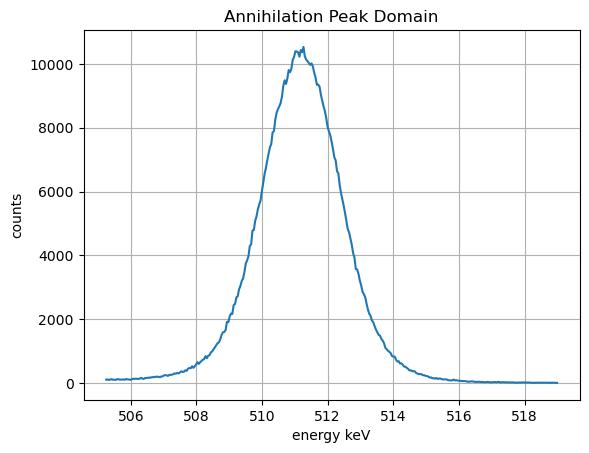

In [9]:
annihilation_domain = finder.domain(spectrum, 511.0)
print(spectrum.axis[annihilation_domain.start], spectrum.axis[annihilation_domain.stop])

annihilation_domain.plot()
plt.title("Annihilation Peak Domain")
plt.ylabel("counts")
plt.xlabel("energy keV")
plt.grid(True, which='both')

# Domain Analysis 
The analysis of domain can be done directly from data or data with error property\
Also there is the domain_analysis module which contains methods for analysis.

In [10]:
from pyspectrum.domain_analysis.single_peak import center_estimator, fwhm_estimator
from pyspectrum.domain_analysis.background import domain_erf_background

In [23]:
# You can analyze the peaks fwhm, center, and background
print(f" center {center_estimator(annihilation_domain)}, and fwhm -{fwhm_estimator(annihilation_domain)}")
 
estimated_background = domain_erf_background(annihilation_domain)
# subtraction returns subtracted domain
# Note the pySpectrum handles the error for you
subtracted_domain = annihilation_domain.subtract_background(estimated_background)

 center 511.1984+/-0.0009, and fwhm -2.6993062945404063


Text(0, 0.5, 'counts')

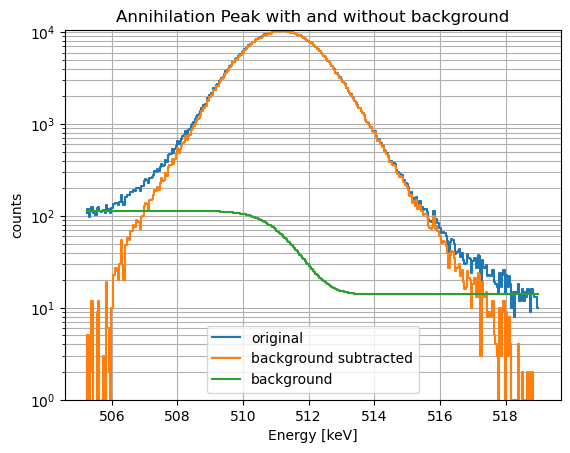

In [24]:
annihilation_domain.plot.step(yscale='log', label='original')
subtracted_domain.data.plot.step(label='background subtracted')
plt.step(annihilation_domain.data.energy, estimated_background, label='background')
plt.legend()
plt.ylim([1, annihilation_domain.max()])
plt.grid(True, which='both')
plt.title('Annihilation Peak with and without background')
plt.xlabel('Energy [keV]')
plt.ylabel('counts')

# Full Domains identification

In [29]:
conv = Convolution(resolution=res_calib.apply, kernel=gaussian_2_dev, window_fwhm=4)
finder = SNRFinder(convolution=conv, n_sigma_signal_threshold=4, n_sigma_bg_threshold=2, persistence_factor=0.5)
domains = finder.find(spectrum)

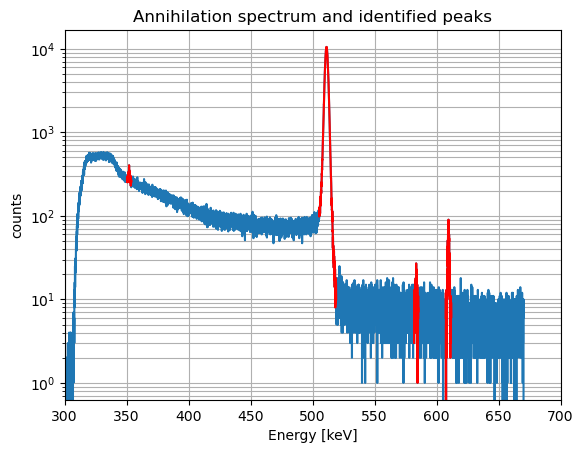

In [31]:
spectrum.plot(yscale='log')
for domain in domains:
    domain.plot(color='red')
plt.xlim([300, 700])
plt.grid(True, which='both')
plt.title('Annihilation spectrum and identified peaks')
plt.xlabel('Energy [keV]')
plt.ylabel('counts')
plt.show()

example how to use a domain analysis methods - 

In [32]:
from pyspectrum.domain_analysis.moment import centroid

In [38]:
# domain can be used as an xarray
max_counts = domains[-1].data.max()
half_max = max_counts / 2
mean_energy = (domains[-1].data.energy * domains[-1].data).sum() / domains[-1].data.sum()
# but there are already made methods for estimations 
centroid(domain), center_estimator(domain)

(np.float64(609.5594859403525), 609.5824814536302+/-0.007249115283226763)

In [39]:
# resolution can be taken from the calibration or from estimators
fwhm = domains[-1].local_resolution
print(f"fwhm from calibration - {fwhm:.2f}, and from direct estimation {fwhm_estimator(domain):.2f}")

fwhm from calibration - 1.15, and from direct estimation 1.24


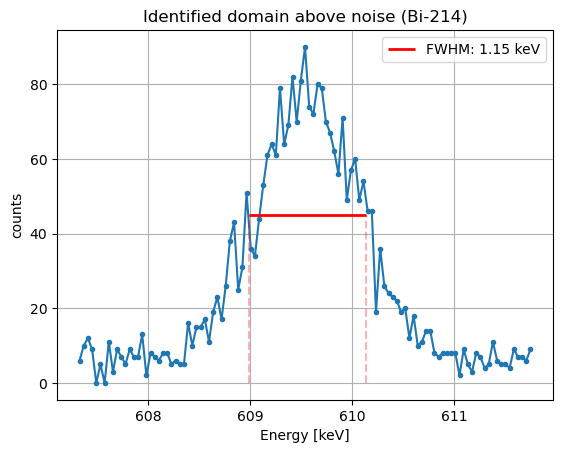

In [42]:
domains[-1].plot(marker='.')
plt.grid(True, which='both')
plt.title('Identified domain above noise (Bi-214)')
plt.xlabel('Energy [keV]')
plt.ylabel('counts')


plt.hlines(y=half_max, 
           xmin=mean_energy - (fwhm / 2), 
           xmax=mean_energy + (fwhm / 2), 
           colors='r', linestyles='-', lw=2, label=f'FWHM: {fwhm:.2f} keV')

plt.vlines(x=[mean_energy - (fwhm / 2), mean_energy + (fwhm / 2)], 
           ymin=0, ymax=half_max, colors='r', linestyles='--', alpha=0.3)

plt.legend()
plt.show()